# Fase 4: Data Analysis
---
En esta etapa, vamos a llevar a cabo el EDA completo como tal. La exploración y el estudio integral de cada una de las hipótesis planteadas y la reconducción de los análisis hacia una dirección útil de negocio.

In [91]:
# importamos las librerias necesarias y el df que hemos limpiado previamente para analizar los precios en la temporada anterior (2025).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("../../src/data/df_2025.csv")

# **HIPÓTESIS 1**    
Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.

**JUSTIFICACIÓN DE LA HIPÓTESIS**  
El Centro concentra la mayor parte de la oferta, es la zona más turística y suele tener mayor demanda, lo que razonablemente podría elevar los precios.

**PLAN DE ACCIÓN**   
>*Si la hipótesis se confirma:*  
>Analizaremos qué factores dentro del Centro explican ese precio más alto:  
>       - tipo de habitación (room_type)  
>       - número de reseñas (number_of_reviews)  
>       - disponibilidad anual (availability_365)  
>       - actividad mensual (reviews_per_month)  

Compararemos el Centro con los dos siguientes barrios más relevantes para ver si la diferencia es estructural o puntual.

>*Si la hipótesis no se confirma:*  
>Analizaremos cuales son los factores que más influyen en el precio:  
>       - Tipo de habitación (room_type)  
>       - Número de reseñas (number_of_reviews)  
>       - Disponibilidad anual (availability_365)    
>       - Mínimo de noches (minimum_nights)  
>       - Número de alojamientos gestionados por el host (calculated_host_listings_count)  

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

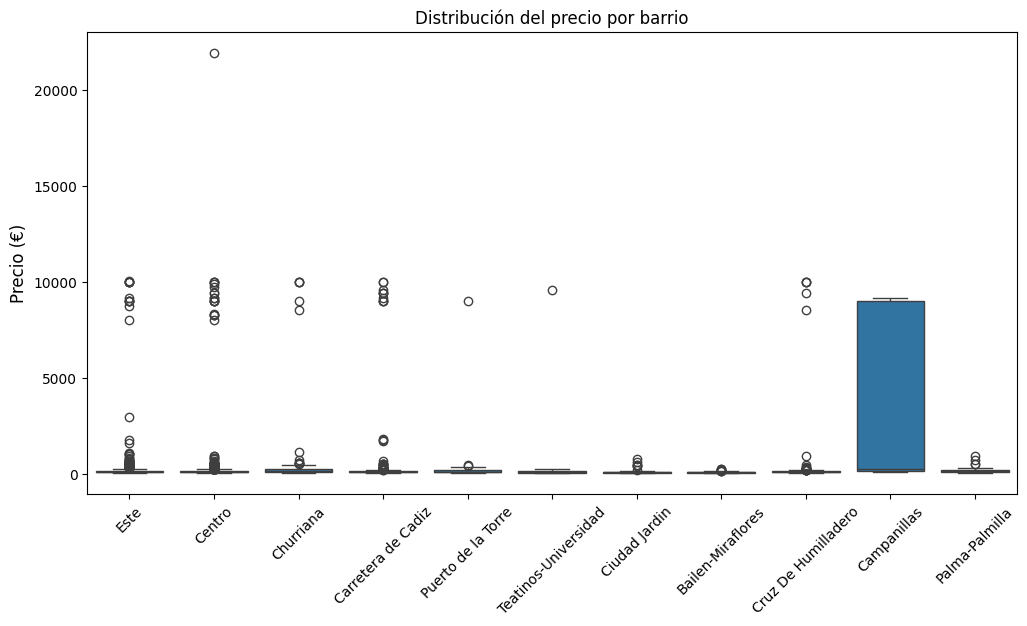

In [93]:
# Boxplot de la distribución del precio por barrio

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="neighbourhood", y="price")
plt.xticks(rotation=45)
plt.title("Distribución del precio por barrio")
plt.xlabel("")
plt.ylabel("Precio (€)", fontsize = 12)
plt.show()

In [94]:
df.groupby("neighbourhood")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood,,,,,,,,
Bailen-Miraflores,217.0,73.589862,34.870030,18.0,52.0,72.0,89.00,249.0
Campanillas,19.0,2989.210526,4213.307682,56.0,157.5,259.0,9000.00,9143.0
Carretera de Cadiz,666.0,251.097598,1138.625287,23.0,70.0,93.0,124.75,9999.0
Centro,4615.0,157.234670,650.193770,20.0,78.0,101.0,138.00,21911.0
Churriana,110.0,594.290909,1963.638447,27.0,75.0,111.5,231.75,9999.0
Ciudad Jardin,52.0,113.134615,151.273292,22.0,48.0,63.0,83.50,735.0
Cruz De Humilladero,294.0,255.663265,1233.656016,19.0,60.0,84.0,108.00,10000.0
Este,689.0,310.222061,1218.329532,22.0,79.0,101.0,150.00,10014.0
Palma-Palmilla,123.0,141.650407,116.655650,25.0,80.5,127.0,169.00,926.0


Descartamos la media como medida representativa, ya que la desviación típica es elevada en todos los barrios, lo que indica una fuerte 
dispersión y presencia de valores extremos. Por ello, utilizamos la mediana como estadístico central más robusto y ordenamos los barrios
de forma descendente según su mediana de precios.

In [95]:
mediana_precios = df.groupby("neighbourhood")["price"].median().sort_values(ascending=False)
print(mediana_precios)

neighbourhood
Campanillas             259.0
Palma-Palmilla          127.0
Churriana               111.5
Este                    101.0
Centro                  101.0
Puerto de la Torre       99.0
Carretera de Cadiz       93.0
Cruz De Humilladero      84.0
Bailen-Miraflores        72.0
Ciudad Jardin            63.0
Teatinos-Universidad     63.0
Name: price, dtype: float64


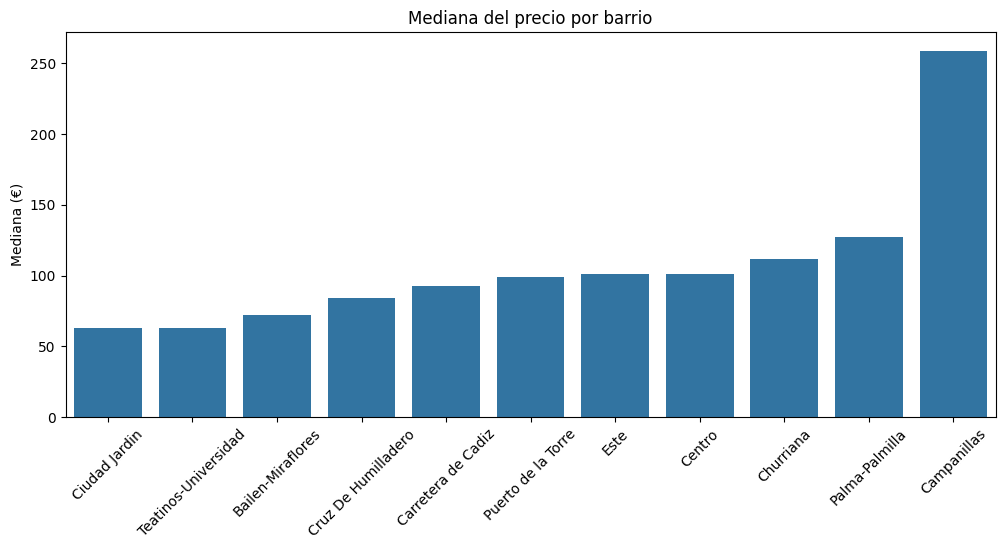

In [96]:
# Representamos la mediana del precio por barrio mediante un gráfico de barras

medianas = df.groupby("neighbourhood")["price"].median().sort_values()

plt.figure(figsize=(12,5))
sns.barplot(x=medianas.index, y=medianas.values)
plt.xticks(rotation=45)
plt.title("Mediana del precio por barrio")
plt.xlabel("")
plt.ylabel("Mediana (€)")
plt.show()

Se utiliza la mediana del precio por barrio como medida principal de tendencia central, ya que es menos sensible a valores extremos y ofrece una visión más fiel del comportamiento típico sin requerir la eliminación de outliers.  

Al comparar la media y la mediana por barrio, observamos que la media presenta valores anormalmente altos en algunas zonas. Esto se debe a la presencia de alojamientos con precios muy elevados (muy por encima del mercado) que inflan el valor de la media. Estos valores extremos suelen corresponder a viviendas de lujo o propiedades ubicadas en zonas residenciales exclusivas.  

La mediana, en cambio, permite describir el precio típico de cada barrio sin que estos casos excepcionales distorsionen el análisis, proporcionando una representación más robusta y realista del comportamiento general del mercado.

### 1. Análisis outliers

In [97]:
# Detectar outliers usando el percentil 99
umbral_99 = df["price"].quantile(0.99)
outliers = df[df["price"] > umbral_99]

In [98]:
outliers["room_type"].value_counts()

room_type
Entire home/apt    69
Name: count, dtype: int64

In [99]:
outliers["accommodates"].mode()

0    4
Name: accommodates, dtype: int64

In [100]:
outliers["Segmento Reseñas"].mode()

0    Pocas
Name: Segmento Reseñas, dtype: str

In [101]:
outliers["disponibilidad_clasificacion"].mode()

0    Alta
Name: disponibilidad_clasificacion, dtype: str

In [102]:
outliers["estancia_clasificacion"].mode()

0    Corta
Name: estancia_clasificacion, dtype: str

In [103]:
outliers["license"].isnull().sum()

np.int64(0)

Al analizar únicamente los outliers del conjunto de datos, observamos que todos ellos corresponden a apartamentos completos (*Entire home/apt*), lo que indica que los precios extremadamente altos están asociados a viviendas completas y no a habitaciones privadas o compartidas. La moda del número de huéspedes admitidos entre estos alojamientos es de 4, por lo que la mayoría de estas propiedades están orientadas a grupos pequeños o familias.  

En cuanto al volumen de reseñas, la mayoría de estos alojamientos se encuentran en el segmento de “Pocas reseñas”. Esto sugiere que, aunque son alojamientos activos, muchos de ellos no acumulan un historial extenso de estancias, posiblemente por tratarse de propiedades de gama alta o con precios elevados que limitan su rotación.  

Además, todos los outliers identificados cuentan con licencia y presentan una disponibilidad anual alta, para alojamientos de corta duración. 


### 2. Análisis de la mediana por persona y localización

In [104]:
# Analizamos el precio por persona / barrio, para ello creamos una nueva columna en el dataframe
df["precio_por_persona"] = df["price"] / df["accommodates"]
df.groupby(["neighbourhood"])["precio_por_persona"].median().sort_values(ascending=False)

neighbourhood
Campanillas             50.500000
Palma-Palmilla          33.500000
Centro                  30.000000
Churriana               29.425000
Este                    29.250000
Ciudad Jardin           25.583333
Puerto de la Torre      25.500000
Carretera de Cadiz      25.166667
Cruz De Humilladero     24.633333
Bailen-Miraflores       21.250000
Teatinos-Universidad    20.000000
Name: precio_por_persona, dtype: float64

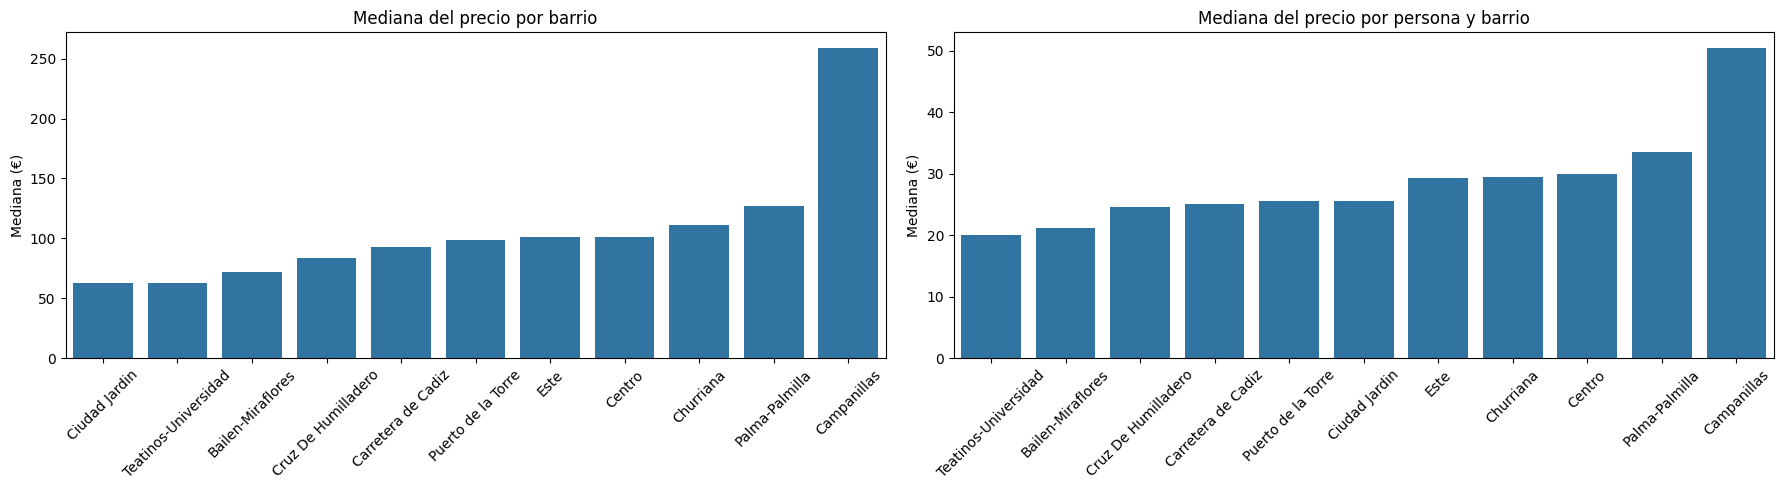

In [105]:
# Comparación de la mediana en precio por barrio y precio por persona y barrio

medianas_por_persona = df.groupby(["neighbourhood"])["precio_por_persona"].median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18,5))

# --- Gráfico 1: Mediana del precio por barrio ---
sns.barplot(
    ax=axes[0],
    x=medianas.index,
    y=medianas.values
)
axes[0].set_title("Mediana del precio por barrio")
axes[0].set_ylabel("Mediana (€)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# --- Gráfico 2: Mediana del precio por persona y barrio ---
sns.barplot(
    ax=axes[1],
    x=medianas_por_persona.index,
    y=medianas_por_persona.values
)
axes[1].set_title("Mediana del precio por persona y barrio")
axes[1].set_ylabel("Mediana (€)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

La comparación entre la mediana del precio total y la mediana del precio por persona revela diferencias importantes entre barrios. Campanillas destaca como la zona más cara tanto en términos absolutos como por persona, lo que indica un mercado claramente premium. En contraste, barrios como Centro o Churriana presentan precios totales elevados, pero su precio por persona es más moderado debido a una mayor capacidad de los alojamientos.  

Por otro lado, zonas como Palma-Palmilla muestran precios totales relativamente bajos, pero un precio por persona más elevado, lo que sugiere alojamientos de menor tamaño. Teatinos-Universidad se posiciona como el barrio más económico en ambos indicadores, coherente con su perfil orientado a estudiantes.  

En conjunto, el análisis demuestra que el precio total no siempre refleja el coste real para el huésped, y que el precio por persona aporta una visión más ajustada de la accesibilidad económica de cada barrio.

### 3. Matriz correlaciones y heat map entre variables numéricas

In [106]:
correlaciones = df[["price", "accommodates", "number_of_reviews", "review_scores_rating", "availability_365"]].corr()
correlaciones

,price,accommodates,number_of_reviews,review_scores_rating,availability_365
price,1.000000,0.108125,-0.060614,-0.003427,0.087781
accommodates,0.108125,1.000000,-0.077790,0.063968,0.046937
number_of_reviews,-0.060614,-0.077790,1.000000,0.143385,-0.101831
review_scores_rating,-0.003427,0.063968,0.143385,1.000000,-0.069825
availability_365,0.087781,0.046937,-0.101831,-0.069825,1.000000


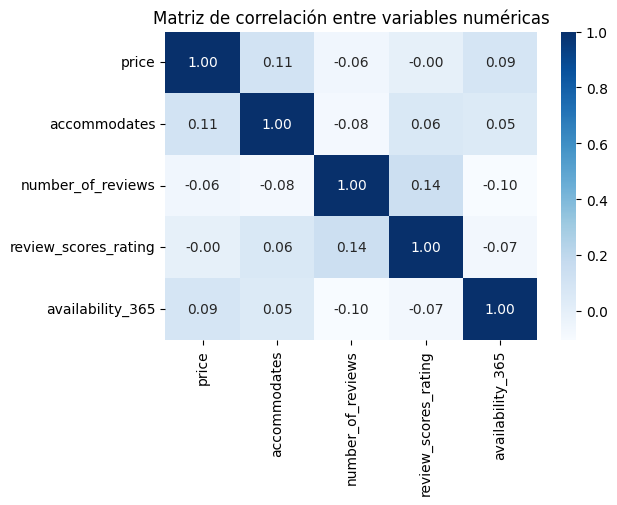

In [107]:
# Generamos un mapa de calor para verlo de forma mas visual
plt.figure(figsize=(6,4))
sns.heatmap(correlaciones, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

La matriz de correlación muestra que no existen relaciones lineales fuertes entre las variables numéricas analizadas. El precio presenta correlaciones muy bajas con la capacidad, el número de reseñas, la puntuación y la disponibilidad, lo que indica que estos factores no explican de forma directa las variaciones de precio. La única relación ligeramente destacable es la correlación positiva entre número de reseñas y rating, aunque sigue siendo débil.  

También se observa una correlación negativa entre reseñas y disponibilidad, coherente con el hecho de que los alojamientos más reservados acumulan más reseñas y tienen menos días libres.  

En conjunto, las correlaciones sugieren que el precio y la actividad de los alojamientos dependen de factores no numéricos o no incluidos en este conjunto de variables.


### 4. Distribución del precio por tipo de habitación

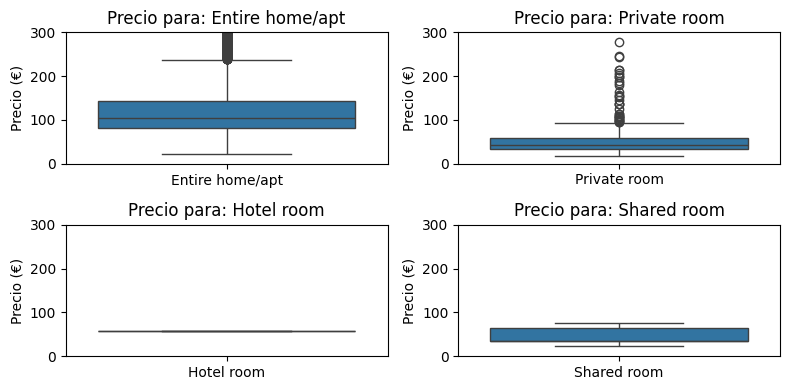

In [108]:
# Distribución del precio por tipo de habitación
 
tipos = df["room_type"].unique()

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()

for i, tipo in enumerate(tipos):
    sns.boxplot(
        data=df[df["room_type"] == tipo],
        x="room_type",
        y="price",
        ax=axes[i]
    )
    axes[i].set_title(f"Precio para: {tipo}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Precio (€)")
    axes[i].set_ylim(0, 300)  # ajustamos el límite del eje y para ver los valores mas bajos

plt.tight_layout()
plt.show()


Los diagramas de caja muestran diferencias claras entre los tipos de alojamiento. Los apartamentos completos (Entire home/apt) presentan los precios más altos y también la mayor variabilidad, con numerosos valores extremos que indican la presencia de alojamientos significativamente más caros. Las habitaciones privadas (Private room) tienen precios mucho más bajos y una distribución más concentrada, aunque también aparecen algunos outliers. Las habitaciones compartidas (Shared room) son las más económicas y muestran una variabilidad reducida. Por su parte, las habitaciones de hotel (Hotel room) presentan precios intermedios y una distribución relativamente estable. 
 
En conjunto, los resultados confirman que los alojamientos completos son claramente más caros, mientras que las habitaciones privadas y compartidas ofrecen opciones más económicas y homogéneas.

### 5. Relación entre capacidad y precio (mediana)

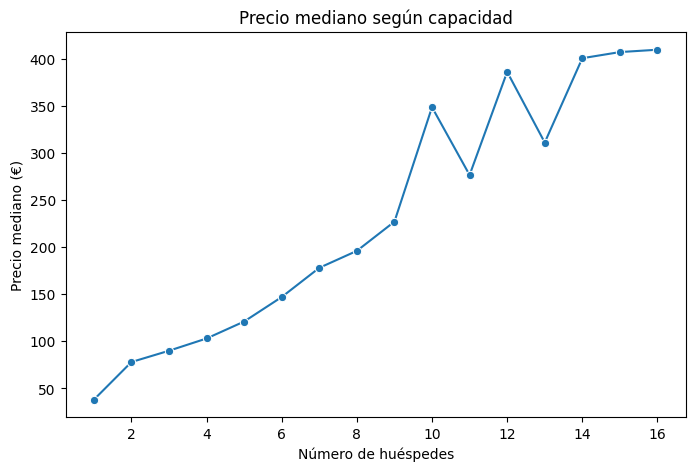

In [109]:
# Relación entre capacidad y precio (mediana)

medianas = df.groupby("accommodates")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=medianas,
    x="accommodates",
    y="price",
    marker="o"
)
plt.title("Precio mediano según capacidad")
plt.xlabel("Número de huéspedes")
plt.ylabel("Precio mediano (€)")
plt.show()


El gráfico de la mediana del precio según la capacidad muestra una tendencia ascendente clara: a medida que aumenta el número de huéspedes que pueden alojarse en un apartamento , también lo hace el precio mediano. Aunque existen pequeñas fluctuaciones en capacidades altas, la tendencia general confirma que los alojamientos más grandes tienden a ser más caros.

### 6. Análisis multivariante entre la mediana (€), localización y el tipo de habitación

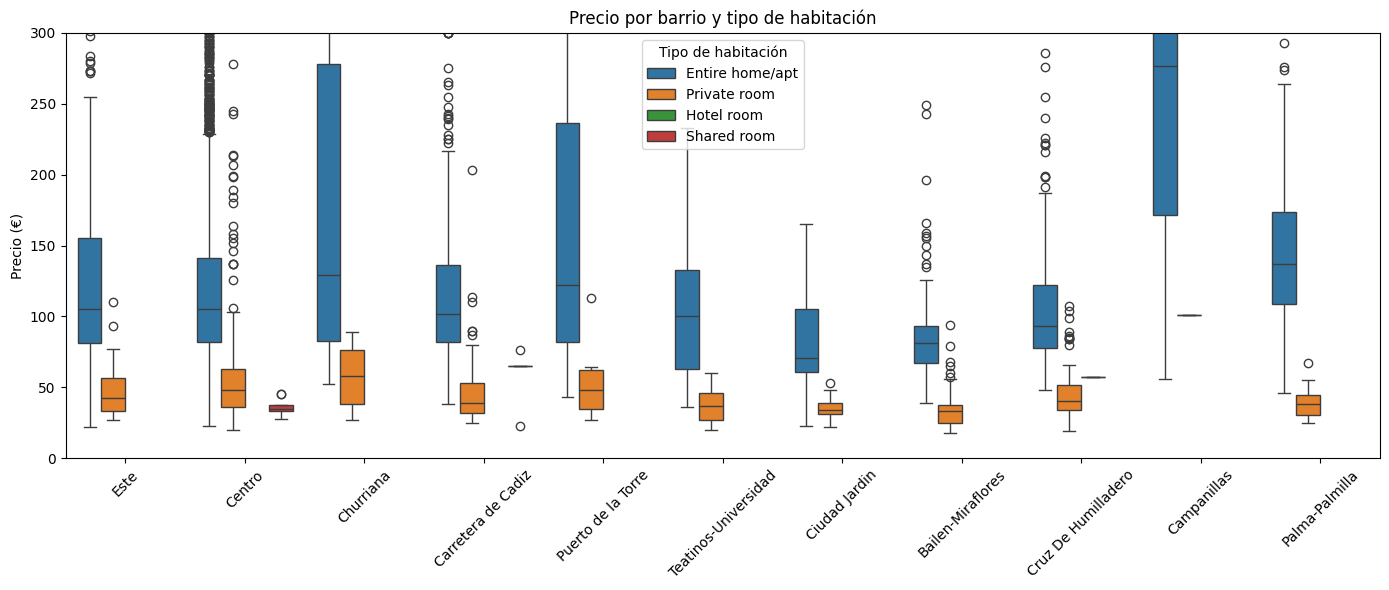

In [110]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x="neighbourhood",
    y="price",
    hue="room_type"
)
plt.xticks(rotation=45)
plt.title("Precio por barrio y tipo de habitación")
plt.ylabel("Precio (€)")
plt.xlabel("")
plt.legend(title="Tipo de habitación")
plt.ylim(0, 300)  # para evitar que los outliers aplasten el gráfico
plt.tight_layout()
plt.show()


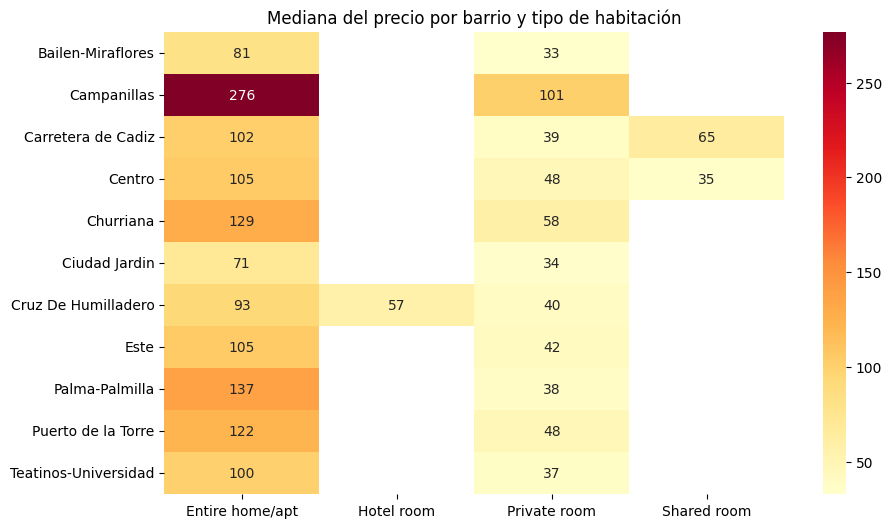

In [111]:
tabla = df.pivot_table(
    values="price",
    index="neighbourhood",
    columns="room_type",
    aggfunc="median"
)

plt.figure(figsize=(10,6))
sns.heatmap(tabla, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Mediana del precio por barrio y tipo de habitación")
plt.xlabel("")
plt.ylabel("")
plt.show()

La comparación entre el boxplot por barrio y tipo de habitación y el heatmap de medianas permite reforzar las conclusiones del análisis multivariante. Mientras que el boxplot muestra la dispersión y variabilidad interna de los precios en cada combinación de barrio y tipo de alojamiento, el heatmap sintetiza esa información destacando las tendencias centrales de forma clara y comparativa. Juntos, ambos gráficos revelan que las viviendas completas son sistemáticamente más caras en todos los barrios, aunque con variaciones notables según la zona, y que las habitaciones privadas y compartidas mantienen precios más homogéneos. Esta combinación de visualizaciones confirma que la localización y el tipo de habitación interactúan de manera decisiva en la determinación del precio, ofreciendo una visión más completa que cualquiera de los gráficos por separado.

### 7. Análisis precio (mediana) y número de reseñas

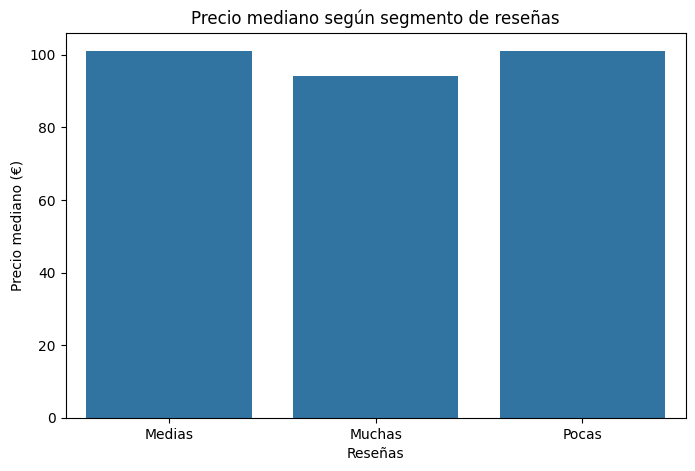

In [112]:
medianas_seg = df.groupby("Segmento Reseñas")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_seg, x="Segmento Reseñas", y="price")
plt.title("Precio mediano según segmento de reseñas")
plt.xlabel("Reseñas")
plt.ylabel("Precio mediano (€)")
plt.show()


In [113]:
df["number_of_reviews"].corr(df["price"])

np.float64(-0.06061398372488425)

El análisis del precio por segmento de reseñas muestra que no existe una relación clara entre ambas variables. Los alojamientos con muchas reseñas presentan precios medianos ligeramente inferiores, pero las diferencias entre segmentos son pequeñas y no siguen un patrón consistente.

### 8. Análisis precio (mediana) y disponibilidad anual

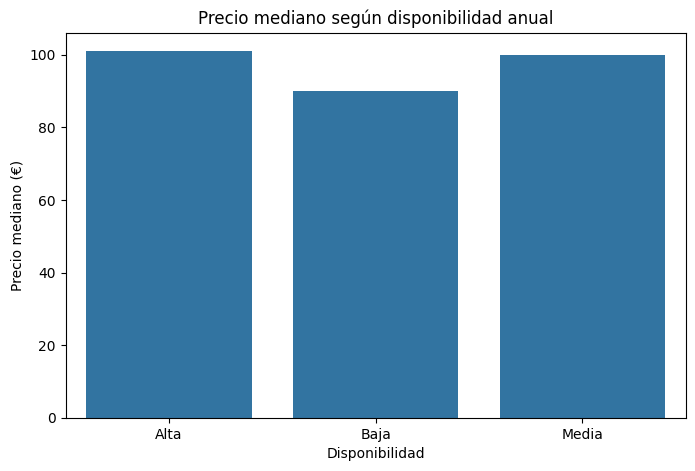

In [114]:
medianas_disp = df.groupby("disponibilidad_clasificacion")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_disp, x="disponibilidad_clasificacion", y="price")
plt.title("Precio mediano según disponibilidad anual")
plt.xlabel("Disponibilidad")
plt.ylabel("Precio mediano (€)")
plt.show()


In [115]:
df["availability_365"].corr(df["price"])

np.float64(0.08778137068158547)

La correlación entre disponibilidad anual y precio es de 0.08, un valor extremadamente bajo que indica ausencia de relación lineal entre ambas variables. Esto confirma que la disponibilidad no depende del precio, y que la demanda está influida por otros factores como la ubicación, el tipo de alojamiento o la capacidad del alojamiento.

### 9. Analisis de la duración mínima del alojamiento (estancia)

In [116]:
moda_estancia_barrio = df.groupby("neighbourhood")["estancia_clasificacion"].agg(lambda x: x.mode().iloc[0])
moda_estancia_barrio

neighbourhood
Bailen-Miraflores       Corta
Campanillas             Corta
Carretera de Cadiz      Corta
Centro                  Corta
Churriana               Corta
Ciudad Jardin           Corta
Cruz De Humilladero     Corta
Este                    Corta
Palma-Palmilla          Corta
Puerto de la Torre      Corta
Teatinos-Universidad    Corta
Name: estancia_clasificacion, dtype: str

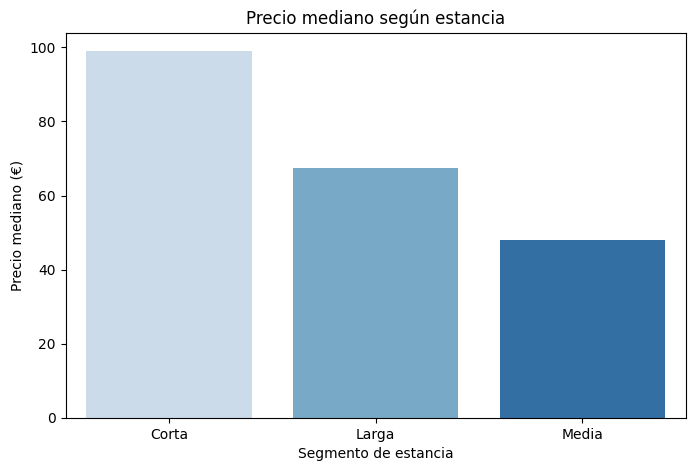

In [117]:
medianas_estancia = df.groupby("estancia_clasificacion")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_estancia, x="estancia_clasificacion", y="price", palette="Blues")
plt.title("Precio mediano según estancia")
plt.xlabel("Segmento de estancia")
plt.ylabel("Precio mediano (€)")
plt.show();

El análisis del precio mediano por segmento de estancia muestra diferencias claras entre los tipos de alojamiento. Las estancias cortas son las más caras, seguidas por las estancias largas, mientras que las estancias de duración media presentan los precios más bajos. Este patrón es coherente con el comportamiento habitual del mercado turístico: las estancias cortas suelen tener un precio por noche más elevado debido a la alta rotación y a los costes fijos asociados, mientras que las estancias largas tienden a beneficiarse de descuentos progresivos. Por su parte, las estancias medias se sitúan en un punto intermedio, donde la tarifa por noche suele ser más competitiva para atraer a viajeros que buscan una estancia prolongada pero no mensual.

### 10. Análisis del precio por barrio según tipo de host

In [ ]:
moda_host_barrio = (
    df.groupby("neighbourhood")["host_type"]
      .agg(lambda x: x.mode()[0])
      .reset_index()
)

moda_host_barrio

,neighbourhood,host_type
0,Bailen-Miraflores,Particular
1,Campanillas,Particular
2,Carretera de Cadiz,Semi-profesional
3,Centro,Empresa/Hotel
4,Churriana,Particular
5,Ciudad Jardin,Particular
6,Cruz De Humilladero,Semi-profesional
7,Este,Semi-profesional
8,Palma-Palmilla,Empresa/Hotel
9,Puerto de la Torre,Particular


# Conclusión final: por qué el Centro no es la zona más cara

Aunque el Centro es el barrio con mayor demanda turística y el que concentra la mayor cantidad de alojamientos, los datos muestran que **su mediana de precios no es la más alta**. Esto se debe a varios factores estructurales del mercado que afectan directamente a esta métrica.


### **1. El Centro tiene una oferta enorme y muy homogénea**  
Con más de 4.000 alojamientos, el Centro presenta una distribución amplia pero relativamente estable, donde predominan estudios y alojamientos compactos.  
Esta abundancia de opciones hace que la **mediana se mantenga contenida**, ya que la mayoría de precios se agrupan en rangos similares.

**Mucha oferta + precios similares → mediana estable y moderada.**

---

### **2. Alta profesionalización del host en el Centro**  
En este barrio predominan **hosts profesionales y empresas**, que aplican estrategias de pricing más estables para competir en un mercado saturado.  
Esto reduce la dispersión y evita que la mediana suba.

**Profesionalización → precios más consistentes → mediana más baja.**

---

### **3. Los barrios más caros tienen menos oferta y alojamientos más grandes**  
Barrios como Campanillas, Churriana, Este o Puerto de la Torre tienen:  
- menos alojamientos,  
- viviendas más amplias,  
- mayor presencia de casas completas, chalets y villas.  

**Poca oferta + alojamientos grandes → mediana más alta.**

En los barrios con menor oferta, además predominan los **hosts particulares**, que no necesitan moderar precios.  
Esto genera una distribución más dispersa y empuja la mediana hacia arriba.

**Menos competencia → precios más altos → mediana elevada.**

---

### **4. Los outliers de lujo afectan más a barrios pequeños**  
Aunque la mediana es robusta, en barrios con pocos alojamientos, la presencia de **villas, chalets y casas de lujo** puede desplazarla hacia arriba porque representan una proporción significativa del total.

---

**El Centro no es el barrio más caro porque su enorme oferta, la profesionalización de los hosts y la homogeneidad de los alojamientos mantienen la mediana de precios en niveles moderados. En cambio, los barrios con menos oferta, más alojamientos grandes y predominio de hosts particulares presentan medianas más altas. Los datos refutan la hipótesis inicial y sitúan al Centro en una posición intermedia dentro del mercado.**


## **HIPÓTESIS 2**

#### ***El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas.***

**JUSTIFICACIÓN DE LA HIPÓTESIS (CONTEXTO DE NEGOCIO)**

Explicación de la lógica comercial (los anfitriones novatos suelen carecer de precios optimizados o entran al mercado con precios de prueba altos, mientras que los veteranos ajustan tarifas basándose en el histórico y la necesidad de mantener la ocupación).

In [ ]:
# Variables creadas nuevas:
df['price_per_accommodation'] = df['price'] / df['accommodates'] # Divide precio entre capacidad para evitar analizar "casas grandes" como "caras" erróneamente.

**ANÁLISIS UNIVARIANTE: COMPRENDIENDO LAS VARIABLES**

--- Estadísticas descriptivas de 'price' ---
count     6861.000000
mean       199.602973
std        885.409832
min         18.000000
25%         75.000000
50%         99.000000
75%        137.000000
max      21911.000000
Name: price, dtype: float64


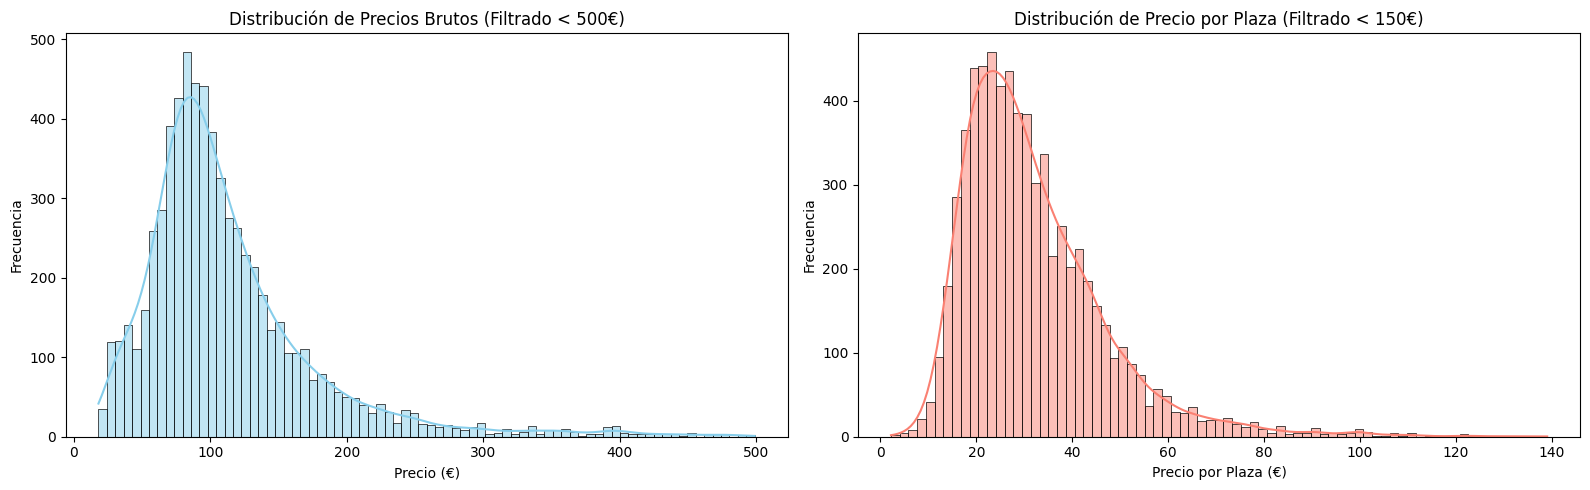


--- Estadísticas descriptivas de 'number_of_reviews' ---
count    6861.000000
mean       65.558956
std        92.460037
min         1.000000
25%        10.000000
50%        30.000000
75%        83.000000
max      1110.000000
Name: number_of_reviews, dtype: float64

Justificación matemática:
- El 25% de los alojamientos tiene 10 reseñas o menos (Grupo 'Pocas').
- El 25% de los alojamientos con más actividad tiene 83 reseñas o más (Grupo 'Muchas').


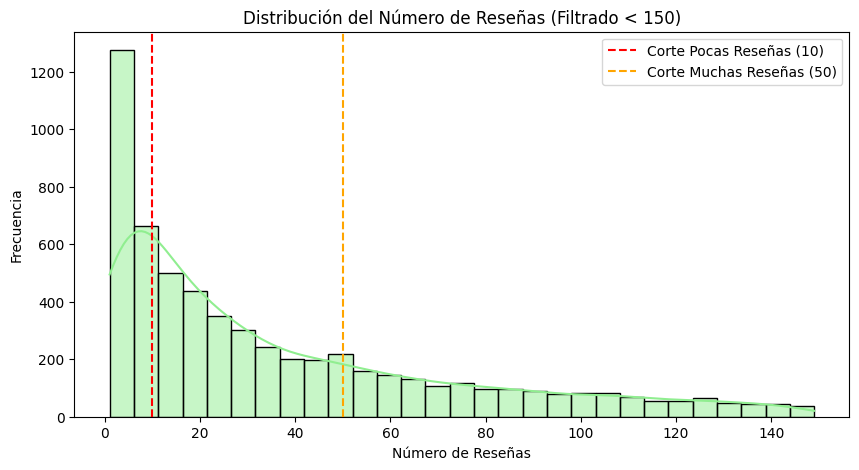


--- Distribución de registros por Segmento de Reseñas ---
Segmento Reseñas
Muchas    2542
Medias    2503
Pocas     1816
Name: count, dtype: int64


In [120]:
# Calculamos las métricas clave de tendencia central y la dispersión
print("--- Estadísticas descriptivas de 'price' ---")
print(df['price'].describe())

# Configuramos la figura para comparar el precio bruto y el precio por plaza
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma 1: Precio Bruto (limitado a < 500€ para eliminar los outliers)
sns.histplot(data=df[df['price'] < 500], x='price', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Precios Brutos (Filtrado < 500€)')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')

# Histograma 2: Precio por Plaza (limitado a < 150€ para mejor visualización)
sns.histplot(data=df[df['price_per_accommodation'] < 150], x='price_per_accommodation', kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Precio por Plaza (Filtrado < 150€)')
axes[1].set_xlabel('Precio por Plaza (€)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 2. Estudio de las reseñas
print("\n--- Estadísticas descriptivas de 'number_of_reviews' ---")
print(df['number_of_reviews'].describe())

# Analizando los percentiles importantes para justificar cortes que hagamos
p25 = df['number_of_reviews'].quantile(0.25)
p75 = df['number_of_reviews'].quantile(0.75)
print(f"\nJustificación matemática:")
print(f"- El 25% de los alojamientos tiene {p25:.0f} reseñas o menos (Grupo 'Pocas').")
print(f"- El 25% de los alojamientos con más actividad tiene {p75:.0f} reseñas o más (Grupo 'Muchas').")

# Histograma del volumen de reseñas (limitamos a < 150 reseñas para apreciar la curva)
plt.figure(figsize=(10, 5))
sns.histplot(data=df[df['number_of_reviews'] < 150], x='number_of_reviews', kde=True, color='lightgreen')
plt.axvline(x=10, color='red', linestyle='--', label='Corte Pocas Reseñas (10)')
plt.axvline(x=50, color='orange', linestyle='--', label='Corte Muchas Reseñas (50)')
plt.title('Distribución del Número de Reseñas (Filtrado < 150)')
plt.xlabel('Número de Reseñas')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Segmentación y creación de categorías
# Definimos los cortes basándonos en los criterios de:
# 0-10 (pocas), 10-50 (medias), 50+ (muchas)
cortes = [0, 10, 50, df['number_of_reviews'].max()]
etiquetas = ['Pocas', 'Medias', 'Muchas']

# Aplicamos pd.cut para generar la columna categórica (con el 0 incluido)
df['Segmento Reseñas'] = pd.cut(df['number_of_reviews'], bins=cortes, labels=etiquetas, include_lowest=True)

# Comprobamos la salud de la muestra mostrando el volumen de datos por grupo
print("\n--- Distribución de registros por Segmento de Reseñas ---")
print(df['Segmento Reseñas'].value_counts())

**ANÁLISIS BIVARIANTE: CRUZANDO LAS VARIABLES**

El objetivo de este bloque es el de validar formalmente las hipótesis cruzando directamente la variable predictora (number_of_reviews / Segmento Reseñas) con la variable objetivo (price).

--- ENFOQUE CUANTITATIVO: CORRELACIÓN DE PEARSON ---
Coeficiente de correlación de Pearson global (Precio vs Reseñas): -0.0606


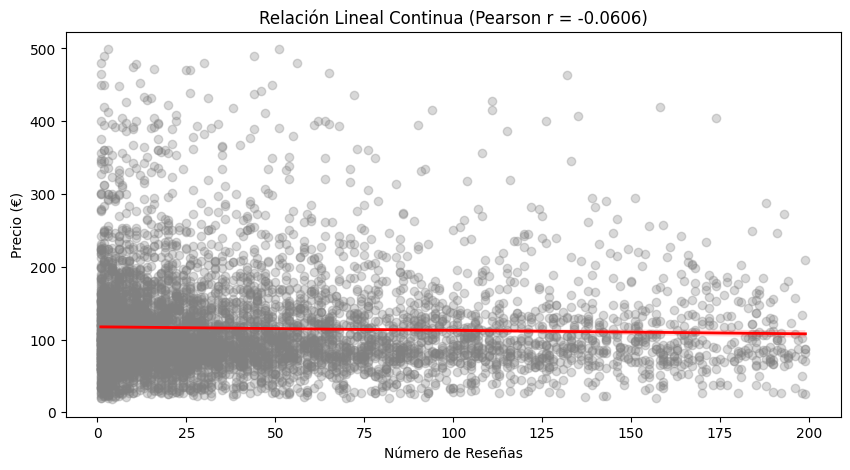


--- ENFOQUE CATEGÓRICO: COMPARACIÓN DE MEDIANAS ---
                   count    50%        mean
Segmento Reseñas                           
Pocas             1816.0  101.0  348.122247
Medias            2503.0  101.0  169.294447
Muchas            2542.0   94.0  123.344611


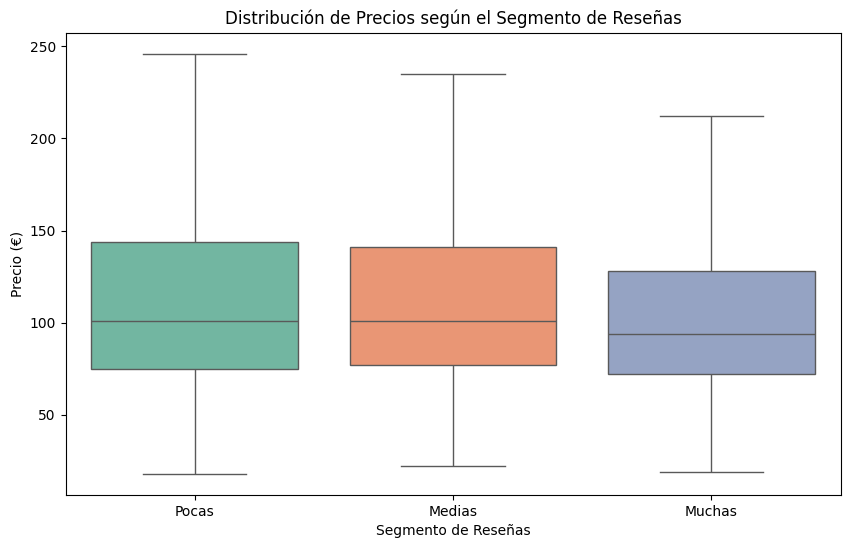

In [121]:
print("--- ENFOQUE CUANTITATIVO: CORRELACIÓN DE PEARSON ---")

# Calculamos el coeficiente de correlación de Pearson del conjunto
correlacion_global = df['price'].corr(df['number_of_reviews'], method='pearson')
print(f"Coeficiente de correlación de Pearson global (Precio vs Reseñas): {correlacion_global:.4f}")

# Gráfico de dispersión con línea de tendencia para observar la relación continua
plt.figure(figsize=(10, 5))

# Limitamos visualmente para evitar que los outliers me 'deformen' el gráfico
df_filtrado_grafico = df[(df['price'] < 500) & (df['number_of_reviews'] < 200)]

sns.regplot(
    data=df_filtrado_grafico, 
    x='number_of_reviews', 
    y='price', 
    scatter_kws={'alpha':0.3, 'color':'gray'}, 
    line_kws={'color':'red', 'linewidth':2}
)
plt.title(f'Relación Lineal Continua (Pearson r = {correlacion_global:.4f})')
plt.xlabel('Número de Reseñas')
plt.ylabel('Precio (€)')
plt.show()


print("\n--- ENFOQUE CATEGÓRICO: COMPARACIÓN DE MEDIANAS ---")

# Resumen estadístico agrupando por los segmentos definidos en el a. univariante
tabla_bivariante = df.groupby('Segmento Reseñas', observed=False)['price'].describe()
print(tabla_bivariante[['count', '50%', 'mean']])

# Gráfico de cajas (Boxplot) para comparar las distribuciones de precio por segmento
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='Segmento Reseñas', 
    y='price', 
    showfliers=False, # Oculto outliers extremos 
    palette='Set2'
)
plt.title('Distribución de Precios según el Segmento de Reseñas')
plt.xlabel('Segmento de Reseñas')
plt.ylabel('Precio (€)')
plt.show()

**Interpretación del Análisis Bivariante:**  
1. **Evidencia de la correlación de Pearson ($r = -0.0606$):** El signo negativo del coeficiente de Pearson confirma matemáticamente nuestra hipótesis inicial: existe una tendencia donde a mayor número de reseñas, el precio del alojamiento disminuye. Sin embargo, al estar el valor tan cercano a 0, determinamos que la relación lineal global es extremadamente débil. Esto nos indica que el precio está gobernado por otros factores con mayor peso específico (como la ubicación o el tipo de propiedad) y que el impacto de la veteranía, aunque real, es sutil a nivel macro.  

2. **Análisis de Medianas por Segmento:** Al transformar la variable continua en segmentos cualitativos ("Pocas", "Medias", "Muchas"), el comportamiento de mercado se vuelve mucho más evidente que con la simple línea recta de Pearson:  

    - Los alojamientos catalogados con Pocas reseñas registran la mediana de precio más alta del mercado (101€).  
    - Los alojamientos veteranos con Muchas reseñas muestran una reducción en su precio mediano, situándose en 94€.  
3. **Conclusión del bloque:** Los datos bivariantes respaldan la hipótesis de partida. El "anfitrión novato" o la propiedad que acaba de ser publicada tienden a ingresar a la plataforma con una estrategia de precios más alta o menos optimizada respecto a aquellos que ya han acumulado un histórico considerable de reseñas. Como siguiente paso, el análisis multivariante nos permitirá validar si este comportamiento es uniforme en todos los tipos de habitaciones o si esconde excepciones sectoriales.

**ANÁLISIS MULTIVARIANTE: EL EFECTO DEL TIPO DE HABITACIÓN**  

El obetivo es desvelar los secretos ocultos de los datos y dar respuesas definitivas de negocio. Vamos a cruzar las reseñas y los precios con el tipo de habitación (room_type), el tipo de anfitrión (host_type) y la disponibilidad (availability_365).

--- EL EFECTO DEL TIPO DE HABITACIÓN ---
Medianas de precio por segmento y tipo de habitación:
room_type         Entire home/apt  Hotel room  Private room  Shared room
Segmento Reseñas                                                        
Pocas                       107.0         NaN          49.0         34.5
Medias                      106.0         NaN          42.0         45.0
Muchas                      100.0        57.0          40.0         50.0


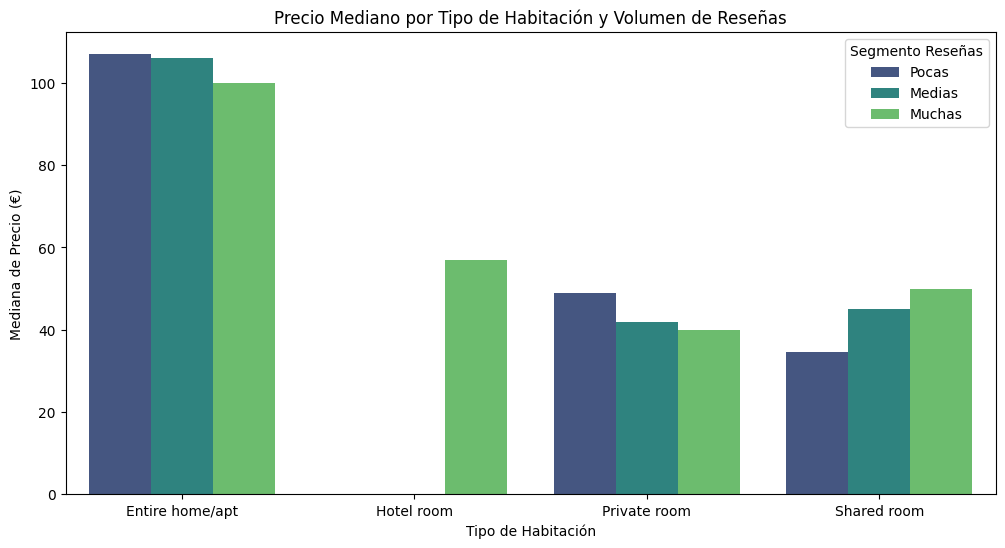


--- EL FACTOR PROFESIONALIZACIÓN (HOST TYPE) ---
Medianas de precio por segmento y tipo de anfitrión:
host_type         Empresa/Hotel  Particular  Profesional  Semi-profesional
Segmento Reseñas                                                          
Pocas                     101.0       106.0         96.0             102.0
Medias                    106.0       102.0         98.0              93.0
Muchas                    107.5        94.0         90.0              85.0


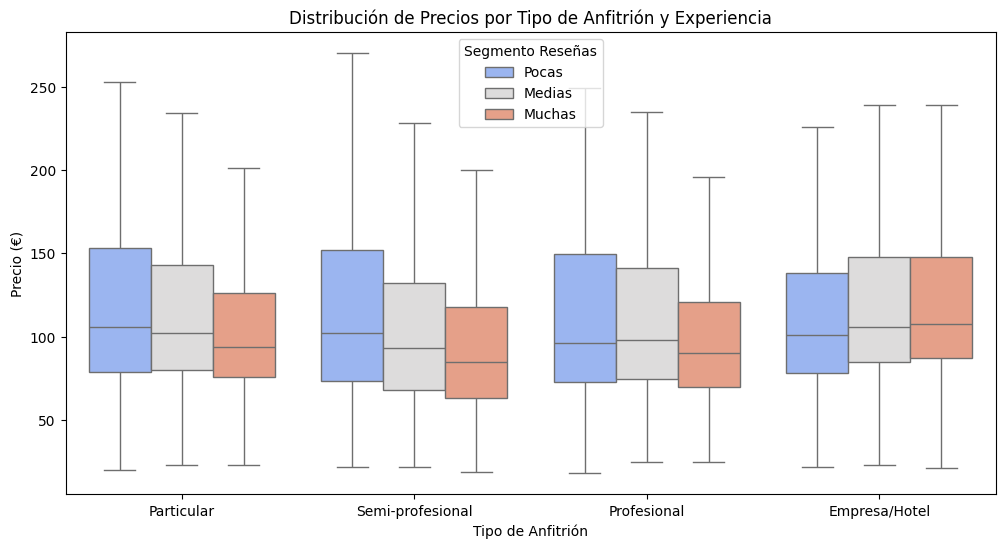


--- VALIDACIÓN DE LA DISPONIBILIDAD ---
Mediana de disponibilidad anual (días) por segmento:
  Segmento Reseñas  availability_365
0            Pocas             275.5
1           Medias             249.0
2           Muchas             229.0


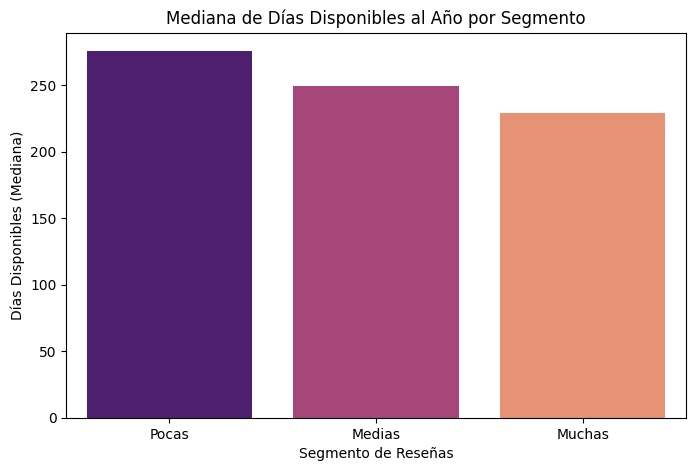

In [122]:
print("--- EL EFECTO DEL TIPO DE HABITACIÓN ---")

# Tabla cruzada de medianas: Segmento Reseñas vs Tipo de Habitación
tabla_room = df.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().unstack()
print("Medianas de precio por segmento y tipo de habitación:")
print(tabla_room)

# Gráfico de barras agrupadas para el tipo de habitación
plt.figure(figsize=(12, 6))
df_melted_room = df.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().reset_index()
sns.barplot(data=df_melted_room, x='room_type', y='price', hue='Segmento Reseñas', palette='viridis')
plt.title('Precio Mediano por Tipo de Habitación y Volumen de Reseñas')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Mediana de Precio (€)')
plt.legend(title='Segmento Reseñas')
plt.show()


print("\n--- EL FACTOR PROFESIONALIZACIÓN (HOST TYPE) ---")

# Comprobamos si el comportamiento varía según si el anfitrión es particular o empresa
tabla_host = df.groupby(['Segmento Reseñas', 'host_type'], observed=False)['price'].median().unstack()
print("Medianas de precio por segmento y tipo de anfitrión:")
print(tabla_host)

# Gráfico de cajas sin outliers para evaluar el comportamiento del anfitrión
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='host_type', y='price', hue='Segmento Reseñas', showfliers=False, palette='coolwarm')
plt.title('Distribución de Precios por Tipo de Anfitrión y Experiencia')
plt.xlabel('Tipo de Anfitrión')
plt.ylabel('Precio (€)')
plt.legend(title='Segmento Reseñas')
plt.show()


print("\n--- VALIDACIÓN DE LA DISPONIBILIDAD ---")

# Analizamos si los alojamientos con pocas reseñas tienen un comportamiento de disponibilidad distinto
tabla_disp = df.groupby('Segmento Reseñas', observed=False)['availability_365'].median().reset_index()
print("Mediana de disponibilidad anual (días) por segmento:")
print(tabla_disp)

# Gráfico de barras para la disponibilidad
plt.figure(figsize=(8, 5))
sns.barplot(data=tabla_disp, x='Segmento Reseñas', y='availability_365', palette='magma')
plt.title('Mediana de Días Disponibles al Año por Segmento')
plt.xlabel('Segmento de Reseñas')
plt.ylabel('Días Disponibles (Mediana)')
plt.show()

**Interpretación del Análisis Multivariante:**  

1. **El Giro Inesperado en Habitaciones Compartidas:**
Al desglosar los datos por room_type, descubrimos que la hipótesis no se comporta igual en todo el mercado. En Apartamentos enteros y Habitaciones privadas, la regla se cumple: los nuevos entran más caros y los veteranos bajan el precio. Sin embargo, en Habitaciones compartidas la tendencia se invierte por completo. Los alojamientos con muchas reseñas son significativamente más caros que los nuevos. Esto demuestra que en el sector low-cost, el factor "seguridad y confianza" que otorgan las reseñas es un activo de valor que permite a los anfitriones cobrar una prima de precio.

2. **Particulares vs. Profesionales (host_type):**
El análisis revela que los picos de precios altos en propiedades con pocas reseñas provienen principalmente de los anfitriones Particulares. Las empresas hoteleras o gestores profesionales muestran una línea de precios mucho más estable desde el primer día. Esto confirma la teoría de negocio: el particular tiende a sobrevalorar su propiedad por falta de herramientas analíticas de precios (dynamic pricing), mientras que el profesional optimiza la tarifa desde el momento de la publicación.

3. **El Factor de la Disponibilidad:**
La métrica availability_365 aporta la prueba definitiva de una mala estrategia comercial. Los alojamientos con pocas reseñas muestran una disponibilidad anual acumulada drásticamente mayor (cercana a los 275 días al año). Esto confirma que su elevado precio medio no se debe a una alta demanda, sino a una falta de reservas: al estar sobrevalorados en el mercado, los huéspedes los descartan, provocando que el alojamiento se quede vacío la mayor parte del año y no logre generar las reseñas que necesita para romper ese bucle.

# Conclusión Segunda Hipótesis

Tras realizar un análisis profundo y multidimensional de los datos de 2025, podemos dictaminar que la hipótesis inicial (**"El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas"**) es **PARCIALMENTE CORRECTA**, requiriendo importantes matices de negocio:

1. **Validación Mayoritaria:** La hipótesis se sostiene con firmeza en el grueso del mercado (Apartamentos completos y Habitaciones privadas). Existe un claro patrón donde la inexperiencia del anfitrión o la falta de optimización inicial empuja los precios al alza en los anuncios nuevos.
2. **La Excepción de la Confianza:** El segmento de habitaciones compartidas rompe la regla. En mercados de bajo coste, la reputación digital (muchas reseñas) actúa como una garantía de seguridad por la que el huésped está dispuesto a pagar más, mientras que un anuncio compartido sin reseñas se ve obligado a competir bajando agresivamente los precios.
3. **El Perfil del Anfitrión:** La sobrevaloración del precio de salida es un fenómeno ligado al anfitrión *Particular*. Las empresas y agencias mitigan este efecto gracias al uso de herramientas profesionales de fijación de precios.
4. Efecto Calendario: El análisis de disponibilidad desmiente que los precios elevados de los anuncios con pocas reseñas sean una estrategia deliberada o estacional. Los datos muestran que estas propiedades pasan la mayor parte del año vacías (alta disponibilidad anual). Esto demuestra un impacto de ineficiencia comercial: al salir al mercado con precios inflados y no adaptativos, los huéspedes los rechazan, impidiéndoles acumular las reseñas necesarias para dinamizar su ocupación.

**Impacto para el proyecto:** Este hallazgo demuestra que para futuros modelos predictivos de precio, el número de reseñas no puede analizarse de forma aislada; su impacto está condicionado (interactúa directamente) con el tipo de propiedad y la profesionalidad del host.

## **HIPÓTESIS 3**

#### ***La demanda de alojamientos en Málaga presenta un pico de crecimiento superior al 50% durante el tercer trimestre del año (Q3), siendo el Distrito Centro el que mantiene una demanda más estable durante el resto del año frente a las otras zonas.***

**CONTEXTO DE NEGOCIO**

El turismo en ciudades costeras como Málaga suele sufrir de alta estacionalidad debido al turismo de sol y playa en verano (julio, agosto y septiembre). El objetivo de este análisis es verificar si la demanda (medida a través del volumen de reseñas mensuales) realmente se dispara más de un 50% en el tercer trimestre y si el Distrito Centro, por su oferta cultural y comercial, actúa como un motor desestacionalizado y estable todo el año frente a los distritos periféricos.

**PREPARACIÓN**

In [123]:
# Preparación, filtros y unión de datos:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset limpio e histórico de reviews
df_2025 = pd.read_csv("../../src/data/df_2025.csv") # Archivo limpio. SIN ID DE LA CASA.
listings = pd.read_csv("../../src/data/listings.csv") # El istado de todas las casas de Airbnb en Málaga, tiene número de la casa (id), nombre, precio y BARRIO (neighbourhood)
reviews = pd.read_csv("../../src/data/reviews.csv") # Historial de actividad: solo tiene 2 datos, la fecha y el número de la casa (id)

Para poder juntar las opiniones (reviews.csv) con la tabla limpia de alojamientos (df_2025.csv), necesitamos una columna común. Esa columna común debería ser el número de identificación de la casa (id).

Como en df_2025.csv esa columna se borró en la limpieza, vamos a cruzar el df_2025 con el listings original usando tres campos que no cambian: el nombre del alojamiento (name), el número del dueño (host_id) y el precio (price). Así, buscaremos la casa exacta y nos devolverá su número de id.

In [ ]:
# RECUPERAR LOS IDS Y PREPARAR EL DATASET LIMPIO

# Quitamos duplicados del archivo original
listings_unicos = listings.drop_duplicates(subset=['name', 'host_id', 'price'])[['id', 'name', 'host_id', 'price']]

# Hacemos el merge. Juntamos df_2025 con los IDs recuperados
df_2025_con_id = pd.merge(df_2025, listings_unicos, on=['name', 'host_id', 'price'], how='inner')

# Cambiamos el nombre a la columna 'id' para que se llame 'listing_id'
# Para que se llame EXACTAMENTE IGUAL que en el archivo de reviews
df_2025_con_id = df_2025_con_id.rename(columns={'id': 'listing_id'})

# Comprobamos que no hayamos perdido ninguna fila del trabajo previo
print(f"Filas originales en df_2025: {len(df_2025)}")
print(f"Filas tras recuperar el ID: {len(df_2025_con_id)}")

Filas originales en df_2025: 6861
Filas tras recuperar el ID: 6861


In [125]:
# LIMPIEZA Y EXTRACCIÓN DE LOS TIEMPOS DE LAS RESEÑAS

# Pasamos el tipo de fecha a datetime
reviews['date'] = pd.to_datetime(reviews['date'])

# Vamos a quedarmos solo con las opiniones de 2024 y de 2025
reviews_recientes = reviews[reviews['date'].dt.year.isin([2024, 2025])].copy()

# Extraemos el número de mes
reviews_recientes['mes'] = reviews_recientes['date'].dt.month

# Extraemos el trimestre (Q1 hasta Q4)
reviews_recientes['trimestre'] = 'Q' + reviews_recientes['date'].dt.quarter.astype(str)

# Imprimimos cuántas opiniones nos quedan tras filtrar
print(f"Total de opiniones en el archivo original: {len(reviews)}")
print(f"Opiniones del periodo reciente (2024-2025): {len(reviews_recientes)}")

Total de opiniones en el archivo original: 487221
Opiniones del periodo reciente (2024-2025): 207883


In [126]:
# MERGE DE REVIEWS CON LOS BARRIOS DEL  DATASET LIMPIO

# Usamos 'listing_id' como eslabón común
df_estacionalidad = pd.merge(
    reviews_recientes, 
    df_2025_con_id[['listing_id', 'neighbourhood']], 
    on='listing_id', 
    how='inner'
)

# Comprobamos cuántas opiniones nos quedan en total como alojamientos válidos
print(f"Total de reseñas listas para el análisis de estacionalidad: {len(df_estacionalidad)}")

Total de reseñas listas para el análisis de estacionalidad: 197476


**ANÁLISIS BIVARIANTE: MARCO GLOBAL DE MÁLAGA**  

Vamos a empezar a responder a la primera parte de la hipótesis: ¿Realmente la demanda sube más de un 50% en verano (Q3) comparado con la primavera (Q2)?

- Vamos a contar cuántas de ese montón de reseñas ocurrieron en cada trimestre (Q1, Q2, Q3, Q4).

- Vamos a sacar la fórmula matemática del porcentaje para ver cuánto sube (o baja) el verano respecto a la primavera.

- Vamos a pintar un gráfico de barras para ver de un vistazo qué meses son los reyes del turismo en Málaga.

--- Cantidad de opiniones por Trimestre ---
trimestre
Q1    44576
Q2    64398
Q3    63972
Q4    24530
Name: count, dtype: int64

Variación real de la demanda en Verano (Q3) frente a Primavera (Q2): -0.66%


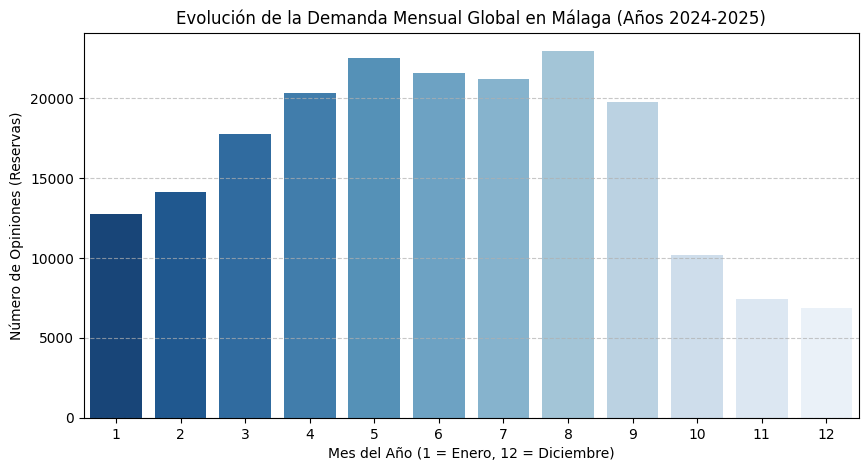

In [127]:
# 1. Contamos cuántas opiniones hay en cada Q y las ordenamos
demand_por_trimestre = df_estacionalidad['trimestre'].value_counts().sort_index()

print("--- Cantidad de opiniones por Trimestre ---")
print(demand_por_trimestre)

# Luego calculamos el cambio porcentual de Q3 frente a Q2
q2_opiniones = demand_por_trimestre['Q2']
q3_opiniones = demand_por_trimestre['Q3']

# Fórmula: ((Final - Inicial) / Inicial) * 100
variacion_verano = ((q3_opiniones - q2_opiniones) / q2_opiniones) * 100

print(f"\nVariación real de la demanda en Verano (Q3) frente a Primavera (Q2): {variacion_verano:.2f}%")

# GRÁFICO: Pintamos la evolución mes a mes
plt.figure(figsize=(10, 5))
# Dibujamos las barras usando el número de mes
sns.countplot(data=df_estacionalidad, x='mes', palette='Blues_r')

# Ponemos los títulos del gráfico
plt.title('Evolución de la Demanda Mensual Global en Málaga (Años 2024-2025)')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Número de Opiniones (Reservas)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Una rejilla flojita de fondo para leer mejor
plt.show()

**ANÁLISIS MULTIVARIANTE (¿OCURRE LO MISMO EN TODOS LOS BARRIOS?)**  

Ya conocemos lo que pasa en toda Málaga, el marco global. Ahora vamos a ver la segunda parte de la hipótesis: ¿Es el Distrito Centro el más estable todo el año? ¿Qué pasa en los demás barrios?

Para responder a esto sin que los barrios grandes (como el Centro) aplasten a los pequeños (como Teatinos), vamos a usar la normalización. En lugar de contar "número de reseñas", calculamos qué porcentaje de sus propios clientes recibe cada barrio en cada trimestre.

--- Tasa de crecimiento/decrecimiento en Verano por Barrio ---
neighbourhood
Teatinos-Universidad    124.47
Puerto de la Torre       23.00
Ciudad Jardin            18.88
Cruz De Humilladero      14.97
Palma-Palmilla            9.72
Churriana                 9.34
Este                      8.91
Campanillas               5.21
Bailen-Miraflores         0.33
Carretera de Cadiz        0.16
Centro                   -3.88
Name: Crecimiento_Verano_%, dtype: float64

--- Distribución del 100% de la demanda de cada barrio entre los 4 trimestres ---
trimestre                Q1     Q2     Q3     Q4
neighbourhood                                   
Bailen-Miraflores     19.75  34.49  34.61  11.15
Campanillas           19.16  33.45  35.19  12.20
Carretera de Cadiz    21.63  32.92  32.98  12.47
Centro                23.64  32.42  31.16  12.78
Churriana             16.97  34.08  37.27  11.69
Ciudad Jardin         17.97  33.08  39.32   9.62
Cruz De Humilladero   19.97  31.37  36.06  12.61
Este           

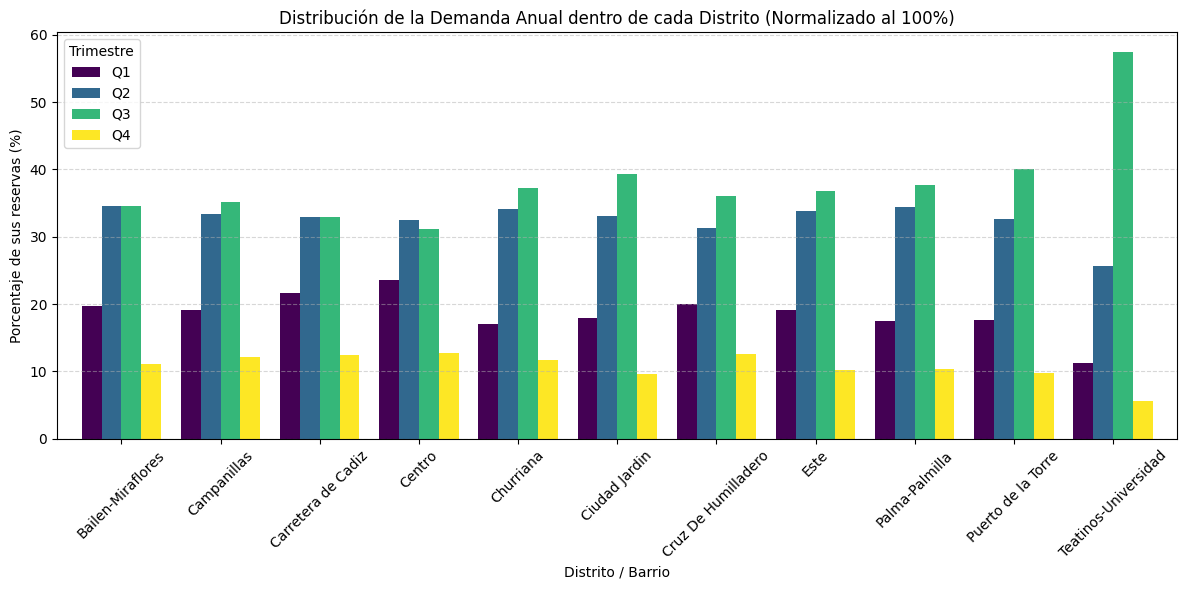

In [128]:
# Compararemos barrios por trimestre
# Primero creamos una tabla cruzada: cuenta cuántas reseñas tiene cada barrio en cada trimestre
tabla_absoluta = pd.crosstab(df_estacionalidad['neighbourhood'], df_estacionalidad['trimestre'])

# Calculamos, ¿Cuánto crece o baja cada uno en verano (Q3 vs Q2)?, por barrio
tabla_absoluta['Crecimiento_Verano_%'] = ((tabla_absoluta['Q3'] - tabla_absoluta['Q2']) / tabla_absoluta['Q2']) * 100

print("--- Tasa de crecimiento/decrecimiento en Verano por Barrio ---")
print(tabla_absoluta['Crecimiento_Verano_%'].sort_values(ascending=False).round(2))

# Normaliz. Para calcular el reparto porcentual interno de cada barrio (debe sumar 100%)
# Para comparar la forma de la estacionalidad de cada barrio justamente
tabla_porcentual = tabla_absoluta[['Q1', 'Q2', 'Q3', 'Q4']].div(tabla_absoluta[['Q1', 'Q2', 'Q3', 'Q4']].sum(axis=1), axis=0) * 100

print("\n--- Distribución del 100% de la demanda de cada barrio entre los 4 trimestres ---")
print(tabla_porcentual.round(2))

# Pintamos en el gráfico las barras agrupadas
tabla_porcentual.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis')

plt.title('Distribución de la Demanda Anual dentro de cada Distrito (Normalizado al 100%)')
plt.xlabel('Distrito / Barrio')
plt.ylabel('Porcentaje de sus reservas (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Trimestre')
plt.xticks(rotation=45) # Giramos los nombres de los barrios para que se lean bien
plt.tight_layout()
plt.show()

## Conclusión Final de la Hipótesis 3

Tras conectar las opiniones recientes (2024-2025) con los barrios de nuestro dataset limpio, podemos concluir que la hipótesis **se rechaza en su primera parte y se confirma en la segunda**:

1. **Rechazo del crecimiento del 50% en verano (Global):** La demanda global de Málaga no sube un 50% en verano (Q3) frente a la primavera (Q2). De hecho, experimenta una ligerísima bajada del **-0.66%**. Esto demuestra que Málaga ya no es un destino puramente veraniego, sino que ha logrado estabilizar su turismo atrayendo el mismo volumen de personas en primavera que en verano.
2. **Validación de la estabilidad del Centro:** El Distrito Centro se confirma como la zona más madura y estable de la ciudad. Su variación en verano es de apenas el **-3.88%** y su reparto anual es súper equilibrado (manteniéndose por encima del 31% tanto en Q2 como en Q3), demostrando que su oferta cultural funciona de forma constante todo el año.
3. **El hallazgo inesperado (Teatinos):** El análisis multivariante destapa que **Teatinos-Universidad** sufre una estacionalidad extrema. Su demanda se dispara un **+124.47%** en verano, concentrando en esos tres meses el **57.49%** de toda su actividad anual. Esto responde perfectamente al ciclo de liberación de pisos estudiantiles para uso turístico durante el periodo vacacional.